<a href="https://colab.research.google.com/github/mgiorgi13/GNN_Notebooks/blob/main/3%20-%20Link%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Link Prediction using Graph Neural Networks


## Setup

In [ ]:
# Colab
from google.colab import drive
drive.mount('/content/drive')
GNN_PATH = '/content/drive/MyDrive/Colab Notebooks/GNN/'

# # Local
# GNN_PATH = './Colab Notebooks/GNN/'
# import os
# if not os.path.exists(GNN_PATH):
#     os.makedirs(GNN_PATH)

In [ ]:
# Install packages
# !pip install torch torch-geometric scikit-learn matplotlib seaborn dgl

# Check pytorch version and make sure you use a GPU Kernel
!python3 -c "import torch; print(torch.__version__)"
!python3 -c "import torch; print(torch.version.cuda)"
!python3 --version
!nvidia-smi

^C
None
Python 3.12.13
zsh:1: command not found: nvidia-smi


In [ ]:
import itertools
import os

os.environ["DGLBACKEND"] = "pytorch"

import dgl
import numpy as np
import torch
import torch.nn as nn
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the seed once at the beginning
set_seed(42)

## Overview of Link Prediction with GNN

Many applications such as social recommendation, item recommendation,
knowledge graph completion, etc., can be formulated as link prediction,
which predicts whether an edge exists between two particular nodes. This
tutorial shows an example of predicting whether a citation relationship,
either citing or being cited, between two papers exists in a citation
network.

We can formulates the link prediction problem as a binary classification
problem as follows:

-  Treat the edges in the graph as *positive examples*.
-  Sample a number of non-existent edges (i.e. node pairs with no edges
   between them) as *negative* examples.
-  Divide the positive examples and negative examples into a training
   set and a test set.
-  Evaluate the model with any binary classification metric such as Area
   Under Curve (AUC).

## Loading graph and features

In [ ]:
import os
try:
    dataset = dgl.data.CoraGraphDataset(raw_dir=GNN_PATH)
except TypeError:
    # older/newer dgl versions may use save_path instead of raw_dir
    dataset = dgl.data.CoraGraphDataset(save_path=GNN_PATH)

if os.path.exists(os.path.join(GNN_PATH, 'cora_v2.zip')):
    os.remove(os.path.join(GNN_PATH, 'cora_v2.zip'))

DATAPATH = os.path.join(GNN_PATH, 'cora_v2_d697a464')
g = dataset[0]

  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done loading data from cached files.


## Prepare training and testing sets

This tutorial randomly picks 10% of the edges for positive examples in
the test set, and leave the rest for the training set. It then samples
the same number of edges for negative examples in both sets.




In [ ]:
# Split edge set for training, validation and testing
u, v = g.edges()

eids = np.arange(g.num_edges())
eids = np.random.permutation(eids)

# Define split sizes: 70% train, 10% val, 20% test
test_size = int(len(eids) * 0.2)
val_size = int(len(eids) * 0.1)
train_size = g.num_edges() - test_size - val_size

# Split positive edges
test_pos_u, test_pos_v = u[eids[:test_size]], v[eids[:test_size]]
val_pos_u, val_pos_v = u[eids[test_size:test_size+val_size]], v[eids[test_size:test_size+val_size]]
train_pos_u, train_pos_v = u[eids[test_size+val_size:]], v[eids[test_size+val_size:]]

# Sample negative edges with DGL
num_neg = g.num_edges()
neg_u, neg_v = dgl.sampling.global_uniform_negative_sampling(g, num_neg)

# Split negative edges
neg_eids = torch.randperm(num_neg)
test_neg_u, test_neg_v = (
    neg_u[neg_eids[:test_size]],
    neg_v[neg_eids[:test_size]],
)
val_neg_u, val_neg_v = (
    neg_u[neg_eids[test_size:test_size+val_size]],
    neg_v[neg_eids[test_size:test_size+val_size]],
)
train_neg_u, train_neg_v = (
    neg_u[neg_eids[test_size+val_size:]],
    neg_v[neg_eids[test_size+val_size:]],
)

When training, you will need to remove the edges in the test set from
the original graph. You can do this via ``dgl.remove_edges``.

With this function you are creating a subgraph from the
   original graph, resulting in a copy and therefore could be slow for
   large graphs. If so, you could save the training and test graph to
   disk, as you would do for preprocessing.




In [ ]:
train_g = dgl.remove_edges(g, eids[:test_size])

## Define a GraphSAGE model

This tutorial builds a model consisting of two
[GraphSAGE](https://arxiv.org/abs/1706.02216)_ layers, each computes
new node representations by averaging neighbor information. DGL provides
``dgl.nn.SAGEConv`` that conveniently creates a GraphSAGE layer.




In [ ]:
from dgl.nn import SAGEConv

# ----------- 2. create model -------------- #
# build a two-layer GraphSAGE model
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, h_feats, dropout=0.5):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_feats, h_feats, "mean")
        self.conv2 = SAGEConv(h_feats, h_feats, "mean")
        self.dropout = nn.Dropout(dropout)

    def forward(self, g, in_feat):
        h = self.conv1(g, in_feat)
        h = torch.relu(h)
        h = self.dropout(h)
        h = self.conv2(g, h)
        h = self.dropout(h)
        return h

The model then predicts the probability of existence of an edge by
computing a score between the representations of both incident nodes
with a function (e.g. an MLP or a dot product), which you will see in
the next section.

\begin{align}\hat{y}_{u\sim v} = f(h_u, h_v)\end{align}




## Positive graph, negative graph, and ``apply_edges``

DGL recommends you to treat the pairs of nodes as another graph, since
you can describe a pair of nodes with an edge.

In link prediction, you will have a *positive graph* consisting of all the positive examples as
edges, and a *negative graph* consisting of all the negative examples.

The *positive graph* and the *negative graph* will contain the same set
of nodes as the original graph.  This makes it easier to pass node
features among multiple graphs for computation.

The following code constructs the positive graph and the negative graph
for the training set and the test set respectively.




In [ ]:
train_pos_g = dgl.graph((train_pos_u, train_pos_v), num_nodes=g.num_nodes())
train_neg_g = dgl.graph((train_neg_u, train_neg_v), num_nodes=g.num_nodes())

val_pos_g = dgl.graph((val_pos_u, val_pos_v), num_nodes=g.num_nodes())
val_neg_g = dgl.graph((val_neg_u, val_neg_v), num_nodes=g.num_nodes())

test_pos_g = dgl.graph((test_pos_u, test_pos_v), num_nodes=g.num_nodes())
test_neg_g = dgl.graph((test_neg_u, test_neg_v), num_nodes=g.num_nodes())

The benefit of treating the pairs of nodes as a graph is that you can
use the ``DGLGraph.apply_edges`` method, which conveniently computes new
edge features based on the incident nodes’ features and the original
edge features (if applicable).

DGL provides a set of optimized builtin functions to compute new
edge features based on the original node/edge features. For example,
``dgl.function.u_dot_v`` computes a dot product of the incident nodes’
representations for each edge.




In [ ]:
import dgl.function as fn

class DotPredictor(nn.Module):
    def forward(self, g, h):
        # with g.local_scope(), any changes to the graph's data (like node features or edge features)
        # will not affect the original graph outside of this scope.
        with g.local_scope():
            g.ndata["h"] = h
            # Compute a new edge feature named 'score' by a dot-product between the
            # source node feature 'h' and destination node feature 'h'.
            g.apply_edges(fn.u_dot_v("h", "h", "score"))
            # u_dot_v returns a 1-element vector for each edge so you need to squeeze it.
            return g.edata["score"][:, 0]

You can also write your own function if it is complex.
For instance, the following module produces a scalar score on each edge
by concatenating the incident nodes’ features and passing it to an MLP.




In [ ]:
class MLPPredictor(nn.Module):
    def __init__(self, h_feats):
        super().__init__()
        self.W1 = nn.Linear(h_feats * 2, h_feats)
        self.W2 = nn.Linear(h_feats, 1)

    def apply_edges(self, edges):
        """
        Computes a scalar score for each edge of the given graph.

        Parameters
        ----------
        edges :
            Has three members ``src``, ``dst`` and ``data``, each of
            which is a dictionary representing the features of the
            source nodes, the destination nodes, and the edges
            themselves.

        Returns
        -------
        dict
            A dictionary of new edge features.
        """
        h = torch.cat([edges.src["h"], edges.dst["h"]], 1)
        return {"score": self.W2(torch.relu(self.W1(h))).squeeze(1)}

    def forward(self, g, h):
        with g.local_scope():
            g.ndata["h"] = h
            g.apply_edges(self.apply_edges)
            return g.edata["score"]

The builtin functions are optimized for both speed and memory.
It's always recommend to use builtin functions whenever possible.

## Training loop

After you defined the node representation computation and the edge score
computation, you can go ahead and define the overall model, loss
function, and evaluation metric.

The loss function is simply binary cross entropy loss.

The evaluation metric in this tutorial is AUC.




In [ ]:
from sklearn.metrics import roc_auc_score

model = GraphSAGE(train_g.ndata["feat"].shape[1], 16, dropout=0.5)
# You can replace DotPredictor with MLPPredictor.
# pred = MLPPredictor(16)
pred = DotPredictor()

def compute_loss(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score]).view(-1)
    labels = torch.cat(
        [torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]
    ).to(scores.device, dtype=scores.dtype).view(-1)
    return torch.nn.functional.binary_cross_entropy_with_logits(
        scores, labels, reduction="mean"
    )

def compute_auc(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score]).detach().cpu().numpy()
    labels = torch.cat(
        [torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]
    ).detach().cpu().numpy()
    return roc_auc_score(labels, scores)

In [ ]:
# ----------- 3. set up loss and optimizer -------------- #
import matplotlib.pyplot as plt

# Config
lr = 0.01
patience = 400
epoch_number = 2000
log_every = 100
weight_decay = 1e-4

optimizer = torch.optim.Adam(
    itertools.chain(model.parameters(), pred.parameters()),
    lr=lr,
    weight_decay=weight_decay,
 )

# Paths for saving models
os.makedirs(DATAPATH, exist_ok=True)
best_val_model_path = os.path.join(DATAPATH, "best_val_model.pt")
final_model_path = os.path.join(DATAPATH, "final_model.pt")

# ----------- 4. training with early stopping ----------- #
def train_one_epoch():
    model.train()
    pred.train()

    h = model(train_g, train_g.ndata["feat"])
    pos_score = pred(train_pos_g, h)
    neg_score = pred(train_neg_g, h)
    loss = compute_loss(pos_score, neg_score)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


def eval_on_graphs(pos_g, neg_g):
    model.eval()
    pred.eval()
    with torch.no_grad():
        h = model(train_g, train_g.ndata["feat"])
        pos_score = pred(pos_g, h)
        neg_score = pred(neg_g, h)
        loss = compute_loss(pos_score, neg_score).item()
        auc = compute_auc(pos_score, neg_score)
    return loss, auc

In [ ]:
best_val_loss = float("inf")
patience_counter = 0
best_epoch = -1

train_losses = []
val_losses = []

print("Starting training...")

for epoch in range(epoch_number):
    train_loss = train_one_epoch()
    val_loss, val_auc = eval_on_graphs(val_pos_g, val_neg_g)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch
        torch.save(
            {"model": model.state_dict(), "pred": pred.state_dict()},
            best_val_model_path,
        )
    else:
        patience_counter += 1

    if epoch % log_every == 0 or epoch == epoch_number - 1:
        print(
            f"Epoch {epoch} | Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch} (best epoch: {best_epoch}).")
        break

torch.save({"model": model.state_dict(), "pred": pred.state_dict()}, final_model_path)
print("\nTraining completed.")

Starting training...


Epoch 0 | Train Loss: 0.7039 | Val Loss: 0.6948 | Val AUC: 0.4978
Epoch 100 | Train Loss: 0.5241 | Val Loss: 0.5272 | Val AUC: 0.8822
Epoch 200 | Train Loss: 0.4973 | Val Loss: 0.5253 | Val AUC: 0.8772
Epoch 300 | Train Loss: 0.4873 | Val Loss: 0.5282 | Val AUC: 0.8729
Epoch 400 | Train Loss: 0.4789 | Val Loss: 0.5306 | Val AUC: 0.8742
Epoch 500 | Train Loss: 0.4706 | Val Loss: 0.5386 | Val AUC: 0.8675
Early stopping triggered at epoch 593 (best epoch: 193).

Training completed.


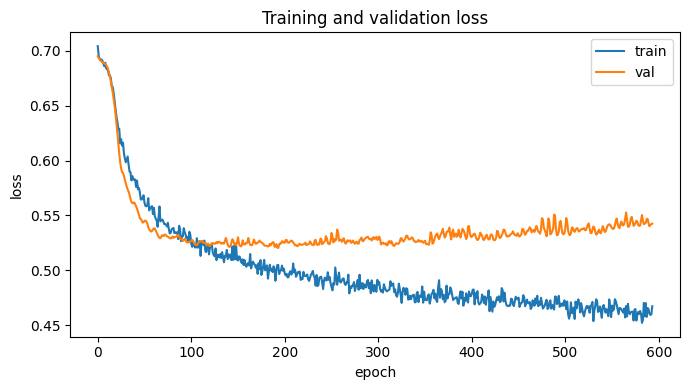

Loaded best model from epoch 193.
Test Loss: 0.5666 | Test AUC: 0.8302


In [ ]:
# Plot training/validation loss
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

# ----------- 5. check results ------------------------ #
if os.path.exists(best_val_model_path):
    checkpoint = torch.load(best_val_model_path, map_location="cpu")
    model.load_state_dict(checkpoint["model"])
    pred.load_state_dict(checkpoint["pred"])
    print(f"Loaded best model from epoch {best_epoch}.")

test_loss, test_auc = eval_on_graphs(test_pos_g, test_neg_g)
print(f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")